#PhlyGreen Tutorial 

Import packages

In [8]:
import sys
sys.path.insert(0,'../')
import PhlyGreen as pg
import numpy as np
import matplotlib.pyplot as plt
import PhlyGreen.Utilities.Units as Units
#import GTEngineHelper  
#import scienceplots

#plt.style.use(['science', 'ieee', 'high-vis'])

Create instances of subsystems. Each one of those requires an Aircraft object as argument. By passing (None) as argument, we are creating empty objects (for the moment).

In [9]:
powertrain = pg.Systems.Powertrain.Powertrain(None)
structures = pg.Systems.Structures.Structures(None)
aerodynamics = pg.Systems.Aerodynamics.Aerodynamics(None)
performance = pg.Performance.Performance(None)
mission = pg.Mission.Mission(None)
weight = pg.Weight.Weight(None)
constraint = pg.Constraint.Constraint(None)
welltowake = pg.WellToWake.WellToWake(None)
battery = pg.Systems.Battery.Battery(None)
climateimpact = pg.ClimateImpact.ClimateImpact(None)

Create instance of Aircraft object.

In [10]:
myaircraft = pg.Aircraft(powertrain, structures, aerodynamics, performance, mission, weight, constraint, welltowake, battery, climateimpact)

Create the connections with its subsystems.

In [11]:
powertrain.aircraft = myaircraft
structures.aircraft = myaircraft
aerodynamics.aircraft = myaircraft
mission.aircraft = myaircraft
performance.aircraft = myaircraft
weight.aircraft = myaircraft
constraint.aircraft = myaircraft
welltowake.aircraft = myaircraft
battery.aircraft = myaircraft
climateimpact.aircraft = myaircraft

Define input dictionaries

In [12]:
ConstraintsInput = {'DISA': 0.,
                    'Cruise': {'Speed': 0.5, 'Speed Type':'Mach', 'Beta': 0.95, 'Altitude': 8000.},
                    'AEO Climb': {'Speed': 210, 'Speed Type':'KCAS', 'Beta': 0.97, 'Altitude': 6000., 'ROC': 5},
                    'OEI Climb': {'Speed': 1.2*34.5, 'Speed Type': 'TAS', 'Beta': 1., 'Altitude': 0., 'Climb Gradient': 0.021},
                    'Take Off': {'Speed': 90, 'Speed Type': 'TAS', 'Beta': 1., 'Altitude': 100., 'kTO': 1.2, 'sTO': 950},
                    'Landing':{'Speed': 59., 'Speed Type': 'TAS', 'Altitude': 500.},
                    'Turn':{'Speed': 210, 'Speed Type': 'KCAS', 'Beta': 0.9, 'Altitude': 5000, 'Load Factor': 1.1},
                    'Ceiling':{'Speed': 0.5, 'Beta': 0.8, 'Altitude': 9500, 'HT': 0.5},
                    'Acceleration':{'Mach 1': 0.3, 'Mach 2':0.4, 'DT': 180, 'Altitude': 6000, 'Beta': 0.9}}

In [13]:
MissionInput = {'Range Mission': 500,  #nautical miles
                'Range Diversion': 220,  #nautical miles
                'Beta start': 0.97,
                'Payload Weight': 4560,  #Kg
                'Crew Weight': 500}  #Kg

In [14]:
MissionStages = {'Takeoff': {'Supplied Power Ratio':{'phi': 0.0}},
                'Climb1': {'type': 'ConstantRateClimb', 'input': {'CB': 0.12, 'Speed': 77, 'StartAltitude': 100, 'EndAltitude': 1500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0}},
                 'Climb2': {'type': 'ConstantRateClimb', 'input': {'CB': 0.06, 'Speed': 110, 'StartAltitude': 1500, 'EndAltitude': 4500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Climb3': {'type': 'ConstantRateClimb', 'input': {'CB': 0.06, 'Speed': 110, 'StartAltitude': 4500, 'EndAltitude': 6500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Cruise': {'type': 'ConstantMachCruise', 'input':{ 'Mach': 0.4, 'Altitude': 6500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0}},
                 'Descent1': {'type': 'ConstantRateDescent', 'input':{'CB': -0.04, 'Speed': 80, 'StartAltitude': 6500, 'EndAltitude': 200}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }}}

DiversionStages = {'Climb1': {'type': 'ConstantRateClimb', 'input': {'CB': 0.03, 'Speed': 110, 'StartAltitude': 200, 'EndAltitude': 3100}, 'Supplied Power Ratio':{'phi_start': 0., 'phi_end':0. }},
                 'Cruise': {'type': 'ConstantMachCruise', 'input':{ 'Mach': 0.3, 'Altitude': 3100}, 'Supplied Power Ratio':{'phi_start': 0., 'phi_end':0.}},
                 'Descent1': {'type': 'ConstantRateDescent', 'input':{'CB': -0.02, 'Speed': 90, 'StartAltitude': 3100, 'EndAltitude': 200}, 'Supplied Power Ratio':{'phi_start': 0., 'phi_end':0. }}}

In [15]:
N_ENGINES = 2.0  # <--- Change this ONE number to update the whole plane (Aero + Systems)
EnergyInput = {'Ef': 43.5*10**6,
                   'Contingency Fuel': 130,
                   'Ebat': 700 * 3600,
                   'pbat': 1000,
                   'Eta Gas Turbine': 0.22,
                   #'Eta Gas Turbine Model': 'Smart', 
                   #'GT Map File': 'GT_Universal_Map.csv',
                   # UNCOMMENT THIS LINE TO FORCE SIZE (in HP):
                   #'GT Design Power': 4000.0, #nominal power of one engine in hp. N.B: if u increase the number of engines for ex by a factor 2 need to divide the powers of the EM and GT by 2!
                   'Eta Propulsive': 0.75,
                   'Eta Gearbox': 0.96,
                   #'Eta Propulsive': 0.9,
                   'Eta Electric Motor 1': 0.96,    #for serial config
                   'Eta Electric Motor 2': 0.96,    #for serial config
                   'Eta Electric Motor': 0.98,      #for parallel config
                   # --- NEW INPUTS FOR HI-FI MOTOR MODEL ---
                   #'EM Design Power': 2000.0,       # kW (Rated Power)
                   #'EM Design Voltage': 800.0,      # V (Bus Voltage)
                   #'EM Design RPM': 11000.0,         # RPM (Rated Speed)
                   # --- SYSTEM INTEGRATION LINK ---
                   'N_Engines_Override': N_ENGINES, # <--- Linked to Global Variable
                   'Eta PMAD': 0.99,
                   'Specific Power Powertrain': [3900,7700],
                   'Specific Power PMAD': [2200,2200,2200],
                   'PowertoWeight Battery': 35, 
                   'PowertoWeight Powertrain': [150,33],
                   'PowertoWeight PMAD': 0
                   }

In [16]:
CellInput = {
    'Class': "I",
    'Model':'Finger-Cell-Thermal',
    'SpecificPower': 8000,
    'SpecificEnergy': 1500,
    'Minimum SOC': 0.2,
    'Pack Voltage':800,
    'Initial temperature': 25,
    'Max operative temperature':50,
    'Ebat': 1000 * 3600, # PhlyGreen uses this input only if Class == 'I'
    'pbat': 1000
    }

In [17]:
AerodynamicsInput = {'AnalyticPolar': {'type': 'Quadratic', 'input': {'AR': 11, 'e_osw': 0.8}},
                    'Take Off Cl': 1.9,
                     'Landing Cl': 1.9,
                     'Minimum Cl': 0.20,
                     'Cd0': 0.017}


PropellerInput = {'Propeller Diameter': Units.ftTom(13),
                  'RPM': 13820/13, # JUST AN ESTIMATION FOR DEBUGGING, 
                  # --- AERODYNAMICS LINK ---
                  'Number of Engines': N_ENGINES,  # <--- Linked to Global Variabl
                  'N_BLADES': 6,
                  'ACTIVITY_FACTOR': 167,
                  'INTEGRATED_LIFT_COEFFICIENT': 0.5
                  } 


In [18]:
WellToTankInput = {'Eta Charge': 0.95,
                   'Eta Grid': 1.,
                   'Eta Extraction': 1.,
                   'Eta Production': 1.,
                   'Eta Transportation': 0.25}

ClimateImpactInput = {'H': 100, 'N':1.6e7, 'Y':30, 'EINOx_model':'Filippone', 'WTW_CO2': 8.30e-3, 'Grid_CO2': 9.36e-2}

Set aircraft power configuration

In [19]:
#myaircraft.Configuration = 'Hybrid'
myaircraft.Configuration = 'Traditional'
myaircraft.HybridType = 'Parallel'
myaircraft.AircraftType = 'ATR'

In [20]:
myaircraft.ConstraintsInput = ConstraintsInput
myaircraft.AerodynamicsInput = AerodynamicsInput
myaircraft.MissionInput = MissionInput
myaircraft.MissionStages = MissionStages
myaircraft.DiversionStages = DiversionStages
myaircraft.EnergyInput = EnergyInput
myaircraft.CellInput = CellInput
myaircraft.WellToTankInput = WellToTankInput
myaircraft.ClimateImpactInput = ClimateImpactInput
myaircraft.PropellerInput = PropellerInput

#powertrain._EtaGTmodelType = 'Smart'
#powertrain.SetInput()
#gt_csv = EnergyInput.get('GT Map File', 'GT_Universal_Map.csv')
#GTEngineHelper.inject_smart_model(powertrain, gt_csv)
#print("System Initialized successfully. Smart Model is active.")

Set inputs

In [21]:
# Initialize Constraint Analysis
myaircraft.constraint.SetInput()

# Initialize Mission profile and Analysis
myaircraft.mission.InitializeProfile()
myaircraft.mission.SetInput()

# Initialize Aerodynamics subsystem
myaircraft.aerodynamics.SetInput()

# Initialize Powertrain
myaircraft.powertrain.SetInput()

# --- FIX: Inject Smart Model if selected ---
#if myaircraft.EnergyInput.get('Eta Gas Turbine Model') == 'Smart':
    #import GTEngineHelper
    # Get the map file name from inputs, default to universal map if missing
    #gt_csv = myaircraft.EnergyInput.get('GT Map File', 'GT_Universal_Map.csv')
    
    # Inject the map and logic into the SPECIFIC aircraft powertrain instance
    #GTEngineHelper.inject_smart_model(myaircraft.powertrain, gt_csv)
    
    #print("Smart Engine Model injected successfully.")

# Initialize Weight Estimator
myaircraft.weight.Class = 'I'

from FLOPS_input import FLOPS_input
myaircraft.FLOPSInput = FLOPS_input

myaircraft.weight.SetInput()

#Initialize Battery Configurator
myaircraft.battery.SetInput()

#Initialized Well to Tank
myaircraft.welltowake.SetInput()

# Initialize Climate Impace Estimator
myaircraft.climateimpact.SetInput()

Either run the Constraint Analysis....

In [22]:
myaircraft.constraint.FindDesignPoint()
print('----------------------------------------')
print('Design W/S: ',myaircraft.DesignWTOoS)
print('Design P/W: ',myaircraft.DesignPW)
print('----------------------------------------')

----------------------------------------
Design W/S:  3293.8228228228227
Design P/W:  194.90567908431782
----------------------------------------


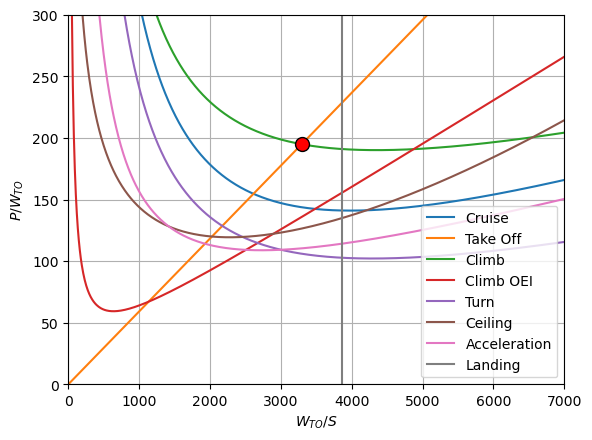

In [23]:
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWCruise, label='Cruise')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWTakeOff, label='Take Off')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWAEOClimb, label='Climb')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWOEIClimb, label='Climb OEI')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWTurn, label='Turn')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWCeiling, label='Ceiling')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWAcceleration, label='Acceleration')
plt.plot(myaircraft.constraint.WTOoSLanding,myaircraft. constraint.PWLanding, label='Landing')
plt.plot(myaircraft.DesignWTOoS, myaircraft.DesignPW, marker='o', markersize = 10, markerfacecolor = 'red', markeredgecolor = 'black')
# plt.plot(performance.WTOoSTorenbeek, performance.PWTorenbeek, label='Torenbeek')
plt.ylim([0, 300])
plt.xlim([0, 7000])
plt.legend()
plt.grid(visible=True)
plt.xlabel('$W_{TO}/S$')
plt.ylabel('$P/W_{TO}$')
plt.show()

... or assign a wing loading

In [24]:
# myaircraft.DesignWTOoS = 3323

Run Mission analysis to define the aircraft's masses

In [25]:
myaircraft.weight.WeightEstimation()

Wing surface can be readily estimated as S = WTO/(WTO/S)

In [26]:
myaircraft.WingSurface = myaircraft.weight.WTO / myaircraft.DesignWTOoS * 9.81

if (myaircraft.Configuration == 'Hybrid' and WellToTankInput is not None):
    myaircraft.welltowake.EvaluateSource()

A summary of the preliminary design:

In [27]:
print('Fuel mass (trip + altn) [Kg]: ', myaircraft.weight.Wf)
print('Block Fuel mass [Kg]:         ', myaircraft.weight.Wf + myaircraft.weight.final_reserve)
if myaircraft.Configuration == 'Hybrid':
    print('Battery mass [Kg]:            ', myaircraft.weight.WBat)
    print('Structure [Kg]:               ', myaircraft.weight.WStructure)
    print('Powertrain mass [Kg]:         ', myaircraft.weight.WPT)
    print('Empty Weight [Kg]:            ', myaircraft.weight.WPT + myaircraft.weight.WStructure + myaircraft.weight.WCrew + myaircraft.weight.WBat)
    print('Zero Fuel Weight [Kg]:        ', myaircraft.weight.WPT + myaircraft.weight.WStructure + myaircraft.weight.WCrew + myaircraft.weight.WBat + myaircraft.weight.WPayload)
else:
    print('Structure [Kg]:               ', myaircraft.weight.WStructure)
    print('Powertrain mass [Kg]:         ', myaircraft.weight.WPT)
    print('Empty Weight [Kg]:            ', myaircraft.weight.WPT + myaircraft.weight.WStructure + myaircraft.weight.WCrew)
    print('Zero Fuel Weight [Kg]:        ', myaircraft.weight.WPT + myaircraft.weight.WStructure + myaircraft.weight.WCrew + myaircraft.weight.WPayload)

print('----------------------------------------')
print('Takeoff Weight: ', myaircraft.weight.WTO)
if myaircraft.WellToTankInput is not None and myaircraft.Configuration == 'Hybrid':
    print('Source Energy: ', myaircraft.welltowake.SourceEnergy/1.e6,' MJ')
    print('Psi: ', myaircraft.welltowake.Psi)
print('Wing Surface: ', myaircraft.WingSurface, ' m^2')
print('TakeOff engine shaft peak power [kW]:      ', myaircraft.mission.TO_PP/1000.)
print('Climb/cruise engine shaft peak power [kW]: ', myaircraft.mission.Max_PEng/1000.)
print('TakeOff battery peak power [kW]:           ', myaircraft.mission.TO_PBat/1000.)
print('Climb/cruise battery peak power [kW]:      ', myaircraft.mission.Max_PBat/1000.)
if myaircraft.Configuration == 'Hybrid':
    if myaircraft.battery.BatteryClass == 'II':
        print('-------------Battery Specs-------------')
        print('Battery Pack Energy [kWh]:           ', myaircraft.battery.pack_energy/1000)
        print('Battery Pack Max Power [kW]:         ', myaircraft.battery.pack_power_max/1000)
        print('Battery Pack Specific Energy [Wh/kg]:',(myaircraft.battery.pack_energy)/myaircraft.weight.WBat)
        print('Battery Pack Specific Power [kW/kg]: ',(myaircraft.battery.pack_power_max/1000)/myaircraft.weight.WBat)
        print('Battery Configuration: ', f"S{myaircraft.battery.S_number} P{myaircraft.battery.P_number}" )

print('-------------Sizing Phase--------------')
#print('Sizing phase for battery: ', 'Cruise energy' if myaircraft.battery.energy_or_power == 'energy' else 'Cruise peak power' if myaircraft.weight.TOPwr_or_CruisePwr == 'cruise' else 'Takeoff peak power'  ) #uncomment when i add a mechanism for seeing which constraint drove what thing in the battery sizing
print('Sizing phase for thermal powertrain ', 'Climb/Cruise peak power' if myaircraft.mission.Max_PEng > myaircraft.mission.TO_PP else 'Takeoff peak power'  )
# print('Sizing phase for electric powertrain ', 'Climb/Cruise peak power' if myaircraft.mission.Max_PBat > myaircraft.mission.TO_PBat else 'Takeoff peak power'  )

Fuel mass (trip + altn) [Kg]:  1701.3901407338503
Block Fuel mass [Kg]:          1831.3901407338503
Structure [Kg]:                10177.340037869155
Powertrain mass [Kg]:          1273.0033744370226
Empty Weight [Kg]:             11950.343412306178
Zero Fuel Weight [Kg]:         16510.343412306178
----------------------------------------
Takeoff Weight:  18341.698274746585
Wing Surface:  54.627121661954284  m^2
TakeOff engine shaft peak power [kW]:       4964.713160304388
Climb/cruise engine shaft peak power [kW]:  3343.0306127347203
TakeOff battery peak power [kW]:            0.0
Climb/cruise battery peak power [kW]:       -0.001
-------------Sizing Phase--------------
Sizing phase for thermal powertrain  Takeoff peak power


In [28]:
print("-" * 40)
print("GAS TURBINE SYSTEM SPECIFICATIONS")
print("-" * 40)

design_watts = powertrain.engineRating
design_hp = Units.wTohp(design_watts)
gt_mass_kg = powertrain.WThermal

print(f"Design Power:    {design_watts/1000:.1f} kW  ({design_hp:.1f} HP)")
print(f"System Mass:     {gt_mass_kg:.1f} kg")
print(f"Power-to-Weight: {(design_hp / gt_mass_kg):.2f} HP/kg")

if hasattr(powertrain, 'GTEngineObj') and powertrain.GTEngineObj.ready:
    print("Status:          Smart Model Active (Physics-based Weight)")
else:
    print("Status:          Constant Specific Power Model")
print("-" * 40)

----------------------------------------
GAS TURBINE SYSTEM SPECIFICATIONS
----------------------------------------
Design Power:    4964.7 kW  (6657.8 HP)
System Mass:     1273.0 kg
Power-to-Weight: 5.23 HP/kg
Status:          Constant Specific Power Model
----------------------------------------


Some plots:

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import math

print("Extracting mission data...")
times = np.array([])
beta = np.array([])

if hasattr(myaircraft.mission, 'integral_solution') and myaircraft.mission.integral_solution:
   
    first_sol = myaircraft.mission.integral_solution[0]
    num_vars = first_sol.y.shape[0]
    
    if num_vars == 2:
        beta_idx = 1 # [Distance, Mass] (Thermal typical)
    elif num_vars >= 3:
        beta_idx = 2 # [Distance, Fuel, Battery] (Hybrid typical)
    else:
        beta_idx = 0 

    for array in myaircraft.mission.integral_solution:
        times = np.concatenate([times, array.t])
        if array.y.shape[0] > beta_idx:
            beta = np.concatenate([beta, array.y[beta_idx]])
        else:
            beta = np.concatenate([beta, array.y[-1]]) 
            
    print(f" -> Found {len(times)} time steps.")
else:
    print(" -> Warning: 'integral_solution' is empty. Using Fallback.")

if len(times) == 0:
    times = np.linspace(0, myaircraft.mission.profile.Time[-1], 200)

if len(beta) == 0:
    print(" -> Warning: Beta not found. Assuming constant weight.")
    beta = np.ones(len(times))

if len(beta) != len(times):
    beta = np.interp(times, np.linspace(0, times[-1], len(beta)), beta)

def get_speed_of_sound(alt_m):
    T = 288.15 - 0.0065 * alt_m
    if isinstance(T, np.ndarray):
        T[T < 0] = 216.65 
    elif T < 0:
        T = 216.65
    return np.sqrt(1.4 * 287.05 * T)

alt_m_trace = myaircraft.mission.profile.Altitude(times)   
vel_ms_trace = myaircraft.mission.profile.Velocity(times) 
mach_trace = vel_ms_trace / get_speed_of_sound(alt_m_trace)

pp_total = [
    (myaircraft.weight.WTO) * myaircraft.performance.PoWTO(
        myaircraft.DesignWTOoS,
        beta[t], 
        myaircraft.mission.profile.PowerExcess(times[t]),
        1,
        alt_m_trace[t],
        myaircraft.mission.DISA,
        vel_ms_trace[t],
        'TAS'
    ) for t in range(len(times))
]

print("Calculating Power Ratios...")
try:
   
    phi_trace = [myaircraft.mission.profile.SuppliedPowerRatio(t) for t in times]
except (TypeError, ValueError, AttributeError):
  
    print(" -> Thermal Configuration detected (Phi undefined). Setting Hybrid Ratio to 0.0.")
    phi_trace = [0.0 for _ in times]

p_ratio_trace = []
for t in range(len(times)):
    try:
    
        res = powertrain.Hybrid(phi_trace[t], alt_m_trace[t], vel_ms_trace[t], pp_total[t])
        p_ratio_trace.append(res)
    except:
        # Fallback if powertrain logic fails on thermal inputs
        # We assume result structure: [P_bat, P_fuel, P_shaft, Throttle_thermal, Throttle_elec]
        # For pure thermal: Shaft = Total, Throttle = 1.0 (placeholder)
        p_ratio_trace.append([0, 0, pp_total[t], 1.0, 0]) 

# Calculate Shaft Power (HP)
shp_trace_hp = []
for t in range(len(times)):
    # Check if the result has the expected structure
    if isinstance(p_ratio_trace[t], (list, tuple, np.ndarray)) and len(p_ratio_trace[t]) > 3:
        # Index 3 is typically the Thermal Throttle/Ratio in this code's convention
        ratio = p_ratio_trace[t][3]
    else:
        ratio = 1.0 
        
    shp_trace_hp.append(Units.wTohp(pp_total[t] / 2) * ratio)


# --- 4. GT Efficiency Loop ---
eta_mission = []   
eta_nominal = []   
power_setting = [] 

design_hp = Units.wTohp(powertrain.engineRating)

if hasattr(powertrain, 'GTEngineObj') and powertrain.GTEngineObj.ready:
    print("Running GT Engine Map prediction...")
    for i in range(len(times)):
        alt_ft = Units.mToft(alt_m_trace[i])
        mach = mach_trace[i]
        shp_required = shp_trace_hp[i]

        _, _, max_p_avail, _ = powertrain.GTEngineObj.predict(
            design_hp, alt_ft, mach, 999999
        )

        # Best efficiency
        p_sweep = np.linspace(0.3 * max_p_avail, max_p_avail, 20)
        eff_sweep = []
        for p in p_sweep:
            eff, _, _, _ = powertrain.GTEngineObj.predict(
                design_hp, alt_ft, mach, p
            )
            eff_sweep.append(eff)
        eta_nominal.append(max(eff_sweep))

        # Actual operating point
        if shp_required < 10:
            eta_mission.append(0)
            power_setting.append(0)
        else:
            eff_act, _, _, _ = powertrain.GTEngineObj.predict(
                design_hp, alt_ft, mach, shp_required
            )
            eta_mission.append(eff_act)
            power_setting.append((shp_required / max_p_avail) * 100)

    # --- 5. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(times / 60, eta_nominal, 'g--', alpha=0.6, label='Potential Max Efficiency')
    ax1.plot(times / 60, eta_mission, 'b-', linewidth=2, label='Actual Mission Efficiency')
    ax1.fill_between(times / 60, eta_mission, eta_nominal, color='red', alpha=0.1, label='Part-Load Penalty')
    ax1.set_title('Engine Efficiency During Mission')
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Efficiency (eta)')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    mask = np.array(power_setting) > 5
    if sum(mask) > 0:
        sc = ax2.scatter(
            np.array(power_setting)[mask],
            np.array(eta_mission)[mask],
            c=np.array(alt_m_trace)[mask],
            cmap='plasma',
            alpha=0.5
        )
        cbar = plt.colorbar(sc, ax=ax2)
        cbar.set_label('Altitude [m]')
    else:
        ax2.text(50, 0.2, "No active power data", ha='center')

    ax2.set_title('Impact of Throttle Setting on Efficiency')
    ax2.set_xlabel('Power Setting (% of Max Available)')
    ax2.set_ylabel('Actual Efficiency')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 105)

    plt.tight_layout()
    plt.show()

else:
    print("Error: Smart GT Model is not loaded in 'powertrain' object.")

Extracting mission data...
 -> Found 180 time steps.
Calculating Power Ratios...
 -> Thermal Configuration detected (Phi undefined). Setting Hybrid Ratio to 0.0.
Error: Smart GT Model is not loaded in 'powertrain' object.


Analyzing Mission for Configuration: Traditional
Re-calculating power profiles...


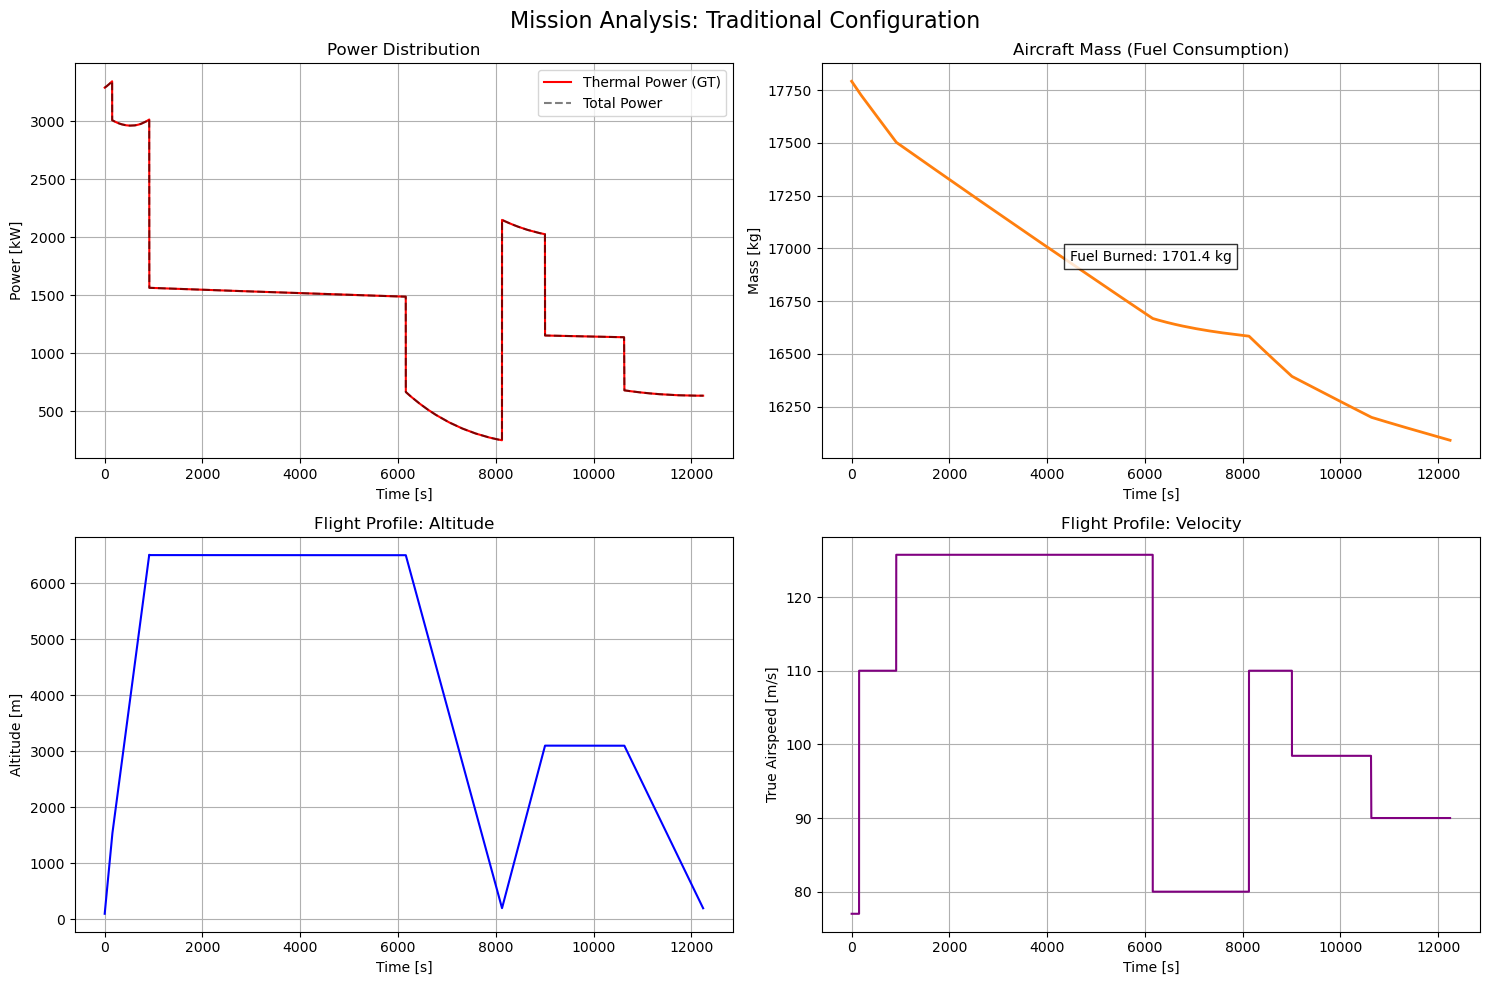

------------------------------
ENERGY SUMMARY
------------------------------
Total Thermal Energy (Shaft): 4523.35 kWh
------------------------------


/var/folders/ld/fnz8sl8x55b2r4ygcnx3w7n80000gn/T/ipykernel_85231/1322966487.py:164: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_thermal_kWh = np.trapz(P_thermal_arr, t_arr) / 3600.0 # kW * s / 3600 -> kWh
/var/folders/ld/fnz8sl8x55b2r4ygcnx3w7n80000gn/T/ipykernel_85231/1322966487.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_elec_kWh = np.trapz(P_batt_arr, t_arr) / 3600.0       # kW * s / 3600 -> kWh


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP & DATA EXTRACTION ---
mis = myaircraft.mission
config = myaircraft.Configuration
print(f"Analyzing Mission for Configuration: {config}")

# Initialize arrays to hold the concatenated history
t_hist = []
beta_hist = [] # Weight fraction (Current Weight / WTO)
ef_hist = []   # Fuel Energy Consumed

# Loop through the integration segments (Takeoff, Climb, Cruise, etc.)
# We need to extract data based on how mission.py saves it:
# Traditional: y = [Ef, Beta]
# Hybrid I:    y = [Ef, EBat, Beta]
# Hybrid II:   y = [Ef, EBat, Beta, Q, T]

for sol in mis.integral_solution:
    t_hist = np.concatenate((t_hist, sol.t))
    
    # Extract Beta (Weight Fraction) based on config indices
    if config == 'Traditional':
        beta_hist = np.concatenate((beta_hist, sol.y[1]))
        ef_hist = np.concatenate((ef_hist, sol.y[0]))
    elif config == 'Hybrid':
        # For both Hybrid Class I and II, Beta is at index 2 (see mission.py)
        beta_hist = np.concatenate((beta_hist, sol.y[2]))
        ef_hist = np.concatenate((ef_hist, sol.y[0]))

# Convert to simple numpy arrays
t_arr = np.array(t_hist)
beta_arr = np.array(beta_hist)

# --- 2. RE-CALCULATE POWER PROFILES ---
# Since the mission integrator only saved Mass/Energy, we must re-run 
# the performance equations to get the Power at every time step.

P_prop_arr = []    # Total Propulsive Power
P_thermal_arr = [] # Engine Power (Fuel based)
P_batt_arr = []    # Battery Power (Electric)
Alt_arr = []       # Altitude
Vel_arr = []       # Velocity

print("Re-calculating power profiles...")

for i, t in enumerate(t_arr):
    # Get flight conditions from the Profile object
    alt = mis.profile.Altitude(t)
    vel = mis.profile.Velocity(t)
    beta = beta_arr[i]
    
    # 1. Calculate Required Propulsive Power (using Performance class)
    # Note: We use PowerExcess=0 or retrieve from profile if available. 
    # The mission code uses mis.profile.PowerExcess(t).
    try:
        excess = mis.profile.PowerExcess(t)
    except:
        excess = 0 # Fallback
        
    PPoWTO = myaircraft.performance.PoWTO(
        myaircraft.DesignWTOoS,
        beta,
        excess,
        1, # n (load factor)
        alt,
        mis.DISA,
        vel,
        'TAS'
    )
    
    P_prop = PPoWTO * mis.WTO
    if P_prop < 0: P_prop = 0 # Clamp negative power
    
    # 2. Calculate Split (Thermal vs Electric) using Powertrain class
    if config == 'Traditional':
        # Returns PRatio array. Index 1 is usually shaft power ratio.
        PRatio = myaircraft.powertrain.Traditional(alt, vel, P_prop)
        P_thermal = P_prop * PRatio[1] 
        P_batt = 0.0
    
    elif config == 'Hybrid':
        # Get Hybrid Split (Phi)
        phi = mis.profile.SuppliedPowerRatio(t)
        PRatio = myaircraft.powertrain.Hybrid(phi, alt, vel, P_prop)
        
        # Based on mission.py: 
        # PRatio[1] is Engine Shaft Power (approx)
        # PRatio[5] is Electric Motor Power Required
        P_thermal = P_prop * PRatio[1]
        P_batt = P_prop * PRatio[5]

    # Store Data
    P_prop_arr.append(P_prop)
    P_thermal_arr.append(P_thermal)
    P_batt_arr.append(P_batt)
    Alt_arr.append(alt)
    Vel_arr.append(vel)

# Convert lists to arrays for plotting
P_thermal_arr = np.array(P_thermal_arr) / 1000.0 # Convert W to kW
P_batt_arr = np.array(P_batt_arr) / 1000.0       # Convert W to kW
Alt_arr = np.array(Alt_arr)
Vel_arr = np.array(Vel_arr)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Mission Analysis: {config} Configuration', fontsize=16)

# Plot 1: Power Distribution
ax[0, 0].plot(t_arr, P_thermal_arr, 'r', label='Thermal Power (GT)')
if config == 'Hybrid':
    ax[0, 0].plot(t_arr, P_batt_arr, 'g', label='Electric Power (Batt)')
    ax[0, 0].plot(t_arr, P_thermal_arr + P_batt_arr, 'k--', label='Total Power', alpha=0.5)
else:
    ax[0, 0].plot(t_arr, P_thermal_arr, 'k--', label='Total Power', alpha=0.5)

ax[0, 0].set_title('Power Distribution')
ax[0, 0].set_ylabel('Power [kW]')
ax[0, 0].set_xlabel('Time [s]')
ax[0, 0].legend()
ax[0, 0].grid(True)

# Plot 2: Energy / Mass
# Calculate Fuel Mass from Energy (Ef)
# Fuel Mass = Ef / (Specific Energy of Fuel * WTO * Beta?? No, simpler:)
# In mission.py: dbetadt = - dEdt/(self.ef*self.WTO). 
# So we can plot the Mass directly using Beta.
current_mass = beta_arr * mis.WTO
ax[0, 1].plot(t_arr, current_mass, 'tab:orange', linewidth=2, label='Aircraft Mass')
ax[0, 1].set_title('Aircraft Mass (Fuel Consumption)')
ax[0, 1].set_ylabel('Mass [kg]')
ax[0, 1].set_xlabel('Time [s]')
ax[0, 1].grid(True)

# Add Fuel Burned Text
fuel_burned = current_mass[0] - current_mass[-1]
ax[0, 1].text(0.5, 0.5, f"Fuel Burned: {fuel_burned:.1f} kg", 
             transform=ax[0, 1].transAxes, ha='center', bbox=dict(facecolor='white', alpha=0.8))

# Plot 3: Altitude
ax[1, 0].plot(t_arr, Alt_arr, 'b')
ax[1, 0].set_title('Flight Profile: Altitude')
ax[1, 0].set_ylabel('Altitude [m]')
ax[1, 0].set_xlabel('Time [s]')
ax[1, 0].grid(True)

# Plot 4: Velocity
ax[1, 1].plot(t_arr, Vel_arr, 'purple')
ax[1, 1].set_title('Flight Profile: Velocity')
ax[1, 1].set_ylabel('True Airspeed [m/s]')
ax[1, 1].set_xlabel('Time [s]')
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --- OPTIONAL: ENERGY SUMMARY ---
print("-" * 30)
print("ENERGY SUMMARY")
print("-" * 30)
# Integrate Power over time (Trapezoidal)
E_thermal_kWh = np.trapz(P_thermal_arr, t_arr) / 3600.0 # kW * s / 3600 -> kWh
E_elec_kWh = np.trapz(P_batt_arr, t_arr) / 3600.0       # kW * s / 3600 -> kWh

print(f"Total Thermal Energy (Shaft): {E_thermal_kWh:.2f} kWh")
if config == 'Hybrid':
    print(f"Total Electric Energy:        {E_elec_kWh:.2f} kWh")
    print(f"Total Mission Energy:         {E_thermal_kWh + E_elec_kWh:.2f} kWh")
print("-" * 30)

In [31]:
print(f"Electric Powertrain Weight (Used in Sizing): {powertrain.WElectric:.2f} kg")

if powertrain.ElectricMotorObj:
    raw_weight = powertrain.ElectricMotorObj.get_weight()
    specs = powertrain.ElectricMotorObj.design_specs
    
    print(f"Hi-Fi Motor Model Weight: {raw_weight:.2f} kg")
    print(f"   -> Single Motor Design: {specs['kw']} kW @ {specs['rpm']} RPM")

    total_em_power = specs['kw'] * N_ENGINES 
    print(f"   -> TOTAL Installed EM Power ({N_ENGINES} engines): {total_em_power:.2f} kW")

ValueError: Electric powertrain Weight unset. Exiting

Total Power Check :

In [ ]:
# =========================================================
# INTEGRATED POWERTRAIN CHECK (GT + High-Fidelity EM)
# =========================================================

import numpy as np

# 1. PASTE YOUR CLASS DEFINITION (Required for EM Check)
class ElectricMotor:
    def __init__(self, design_kw, design_v, design_rpm):
        self.design_specs = {'kw': design_kw, 'v': design_v, 'rpm': design_rpm}
        self.params = self._generate_scaled_params(design_kw, design_v, design_rpm)
        
        # Calculate Rated Efficiency using the EXACT physics function
        w_rated = design_rpm * 2 * np.pi / 60.0
        t_rated = (design_kw * 1000) / w_rated
        self.design_efficiency = self.solve_efficiency(design_rpm, t_rated)
        
    def _generate_scaled_params(self, P_rated_kw, V_bus, RPM_rated):
        Ref_P, Ref_V, Ref_RPM = 750.0, 800.0, 3000.0
        Ref_R, Ref_L, Ref_Inoload = 0.0012, 0.00015, 20.0
        Ref_Pcore, Ref_Pconst, Ref_Windage = 8000.0, 500.0, 2.5e-6
        k_power = P_rated_kw/Ref_P
        k_volt = V_bus/Ref_V
        k_speed = RPM_rated/Ref_RPM
        w_rated = RPM_rated * 2 * np.pi / 60.0
        Kt_new = (V_bus / np.sqrt(3)) * 0.95 / w_rated 
        R_new = Ref_R * (k_volt**2) / k_power
        L_new = Ref_L * (k_volt**2) / k_power
        k_torque = k_power / k_speed
        return {
            'V_bus': V_bus, 'R_phase': R_new, 'Kt': Kt_new, 'Ld': L_new, 'Lq': L_new,
            'I_no_load': Ref_Inoload * k_torque, 'B_viscous': 0.01 * k_torque, 
            'P_core_rated': Ref_Pcore * k_power, 'rpm_rated': RPM_rated,
            'k_windage': Ref_Windage * k_torque, 'P_const': Ref_Pconst * k_power,
            'T_operating': 100.0
        }

    def solve_efficiency(self, rpm, torque, v_bus_override=None):
        current_v = v_bus_override if v_bus_override else self.params['V_bus']
        T_op = self.params.get('T_operating', 100.0)
        R_hot = self.params['R_phase'] * (1.0 + 0.00393 * (T_op - 20.0))
        V_max = current_v / np.sqrt(3)    
        Kt, Ld, Lq = self.params['Kt'], self.params['Ld'], self.params['Lq']
        omega_rad = max(rpm * 2 * np.pi / 60.0, 1e-5)
        T_fric = (self.params['I_no_load'] * Kt) + (self.params['B_viscous'] * omega_rad)
        T_req = torque + T_fric
        i_q = T_req / Kt
        i_d = 0.0
        lambda_pm = Kt
        flux_sq = (Lq * i_q)**2 + lambda_pm**2
        V_est = omega_rad * np.sqrt(flux_sq)
        if V_est > V_max: 
            limit_sq = (V_max / omega_rad)**2
            if limit_sq < (Lq * i_q)**2: return 0.05 
            i_d = (np.sqrt(limit_sq - (Lq * i_q)**2) - lambda_pm) / Ld
        I_mag = np.sqrt(i_q**2 + i_d**2)
        P_copper = 3 * (I_mag**2) * R_hot
        w_rated = self.params['rpm_rated'] * 2 * np.pi / 60.0
        P_core = self.params['P_core_rated'] * (0.5*(omega_rad/w_rated) + 0.5*(omega_rad/w_rated)**2)
        P_wind = self.params['k_windage'] * omega_rad**3
        P_const = self.params['P_const']
        total_loss = P_copper + P_core + P_wind + P_const
        P_out = torque * omega_rad
        if (P_out + total_loss) <= 0: return 0.05
        return P_out / (P_out + total_loss)

# =========================================================
# 2. PERFORM CALCULATIONS
# =========================================================

# --- A. Common Parameters ---
n_engines = myaircraft.PropellerInput.get('Number of Engines', 1.0)
eta_pmad  = myaircraft.EnergyInput.get('Eta PMAD', 0.99)

# --- B. GAS TURBINE (GT) DATA ---
# Installed GT Power (Total) at SEA LEVEL
gt_installed_total_kw = powertrain.engineRating / 1000.0
# Required GT Power (Peak Shaft Power from Mission)
req_gt_peak_kw = myaircraft.mission.Max_PEng / 1000.0

# --- C. ELECTRIC MOTOR (EM) DATA ---
# Installed EM Power
design_kw  = myaircraft.EnergyInput.get('EM Design Power', 2000.0)
design_v   = myaircraft.EnergyInput.get('EM Design Voltage', 800.0)
design_rpm = myaircraft.EnergyInput.get('EM Design RPM', 3000.0)
installed_em_mech_total = design_kw * n_engines

# Calculate Efficiency using Class
real_motor = ElectricMotor(design_kw, design_v, design_rpm)
eta_em_real = real_motor.design_efficiency

# Required EM Power (derived from Battery Peak)
req_bat_elec_total = myaircraft.mission.Max_PBat / 1000.0
req_em_mech_total = req_bat_elec_total * eta_pmad * eta_em_real

# =========================================================
# 3. PRINT INTEGRATED REPORT
# =========================================================
print("=" * 60)
print("       POWERTRAIN CAPACITY ANALYSIS")
print("=" * 60)

# ----------------- SECTION 1: GAS TURBINE (GT) CHECK (UPDATED) -----------------
print(f"1. GAS TURBINE (GT) CHECK")
print("-" * 30)

# A. INTELLIGENT DETECTION (Altitude & Hybrid Phi)
max_altitude_m = None
cruise_phi = 0.0

try:
    # 1. Find the Dictionary
    stages_dict = None
    if 'MissionStages' in globals():
        stages_dict = globals()['MissionStages']
    elif hasattr(myaircraft.mission, 'MissionStages'):
        stages_dict = myaircraft.mission.MissionStages

    # 2. Extract Data from 'Cruise' stage
    if stages_dict and 'Cruise' in stages_dict:
        cruise_stage = stages_dict['Cruise']
        
        # Altitude
        if 'input' in cruise_stage:
            val = cruise_stage['input'].get('Altitude')
            if val is not None: max_altitude_m = float(val)
        
        # Hybrid Factor (Phi)
        if 'Supplied Power Ratio' in cruise_stage:
            spr = cruise_stage['Supplied Power Ratio']
            p_start = spr.get('phi_start', 0.0)
            p_end = spr.get('phi_end', 0.0)
            cruise_phi = (p_start + p_end) / 2.0 # Average Phi

    # 3. Fallback for Altitude if not found
    if max_altitude_m is None:
        alt_attr = myaircraft.mission.profile.Altitude
        if callable(alt_attr): max_altitude_m = np.max(alt_attr())
        else: max_altitude_m = np.max(alt_attr)

except Exception as e:
    print(f"   [!] Detection warning ({e}). Using Defaults.")
    max_altitude_m = 7000.0

if max_altitude_m is None: max_altitude_m = 7000.0

# B. CALCULATE POWER LOSS (SIGMA)
temp_ratio = 1 - (0.0065 * max_altitude_m / 288.15)
if temp_ratio < 0: temp_ratio = 0.001
sigma = temp_ratio ** 5.2561

# C. CALCULATE AVAILABLE & REQUIRED
gt_avail_cruise = gt_installed_total_kw * sigma

# [CRITICAL STEP] Estimate Cruise Requirement
# We don't have exact 'Cruise Power' variable, but we can assume the engine
# is sized to handle the mission peak.
# If 'req_gt_peak_kw' is the PEAK GT power recorded, it is likely during Climb/Takeoff.
# For Cruise check, we should check if the engine fits the *Cruise* condition.
# Let's trust the 'phi' factor: GT only needs to provide (1 - phi) of the Load.

print(f"   Mission Context:")
print(f"    - Cruise Altitude:      {max_altitude_m:.1f} m")
print(f"    - Cruise Hybrid Phi:    {cruise_phi:.2f} (Electric Split)")
print(f"    - Air Density Factor:   {sigma:.3f}")
print("-" * 30)
print(f"   Power Analysis:")
print(f"    - Installed (Sea Level): {gt_installed_total_kw:.2f} kW")
print(f"    - GT Available @ Cruise: {gt_avail_cruise:.2f} kW")
print(f"    - Mission Peak Recorded: {req_gt_peak_kw:.2f} kW (Likely Takeoff/Climb)")

# D. THE CHECK
# We perform two checks: 
# 1. Total Power (Safety) 
# 2. Cruise Sustainability (incorporating Phi)

if gt_avail_cruise >= (req_gt_peak_kw * (1 - cruise_phi)):
    # If the derated engine can handle the peak load *helped* by the electric motor
    margin = gt_avail_cruise - (req_gt_peak_kw * (1 - cruise_phi))
    print("-" * 30)
    print(f"   STATUS: SUCCESS ✅")
    print(f"   Reason: Hybrid assistance (Phi={cruise_phi}) reduces GT load.")
    print(f"   Estimated Margin: {margin:.2f} kW")
elif gt_installed_total_kw >= req_gt_peak_kw:
    # If engine is big enough for peak (Takeoff) but small for cruise?
    print("-" * 30)
    print(f"   STATUS: WARNING ⚠️")
    print(f"   GT is sized for Takeoff, but might struggle at {max_altitude_m}m without Hybrid help.")
else:
    print("-" * 30)
    print(f"   STATUS: FAILED ❌")
    print(f"   Action: Increase GT Power.")
    
print("-" * 60)

# ----------------- SECTION 2: ELECTRIC MOTOR --------------
print(f"2. ELECTRIC MOTOR (EM) CHECK")
print("-" * 30)
print(f"   Model Specs: {design_kw}kW | {design_v}V | {design_rpm}RPM")
print(f"   Efficiencies: EM={eta_em_real:.4f} | PMAD={eta_pmad:.4f}")
print("-" * 30)
print(f"   Battery Peak (Elec):         {req_bat_elec_total:.2f} kW")
print(f"   Required EM Shaft (Mech):    {req_em_mech_total:.2f} kW")
print(f"   Installed EM Shaft (Mech):   {installed_em_mech_total:.2f} kW")

if installed_em_mech_total >= req_em_mech_total:
    margin_em = installed_em_mech_total - req_em_mech_total
    print(f"   STATUS: SUCCESS ✅ (Margin: {margin_em:.2f} kW)")
else:
    deficit_em = req_em_mech_total - installed_em_mech_total
    print(f"   STATUS: FAILED ❌ (Deficit: {deficit_em:.2f} kW)")
    print(f"   ACTION: Increase 'EM Design Power'.")

print("=" * 60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

motor = powertrain.ElectricMotorObj
print(f"Plotting Map for: {motor.design_specs['kw']} kW @ {motor.design_specs['rpm']} RPM")
rpm_range = np.linspace(0, motor.design_specs['rpm'] * 1.2, 50)  # Go up to 120% speed
torque_max = (motor.design_specs['kw'] * 1000) / (motor.design_specs['rpm'] * 2 * np.pi / 60)
torque_range = np.linspace(0, torque_max * 1.2, 50)              # Go up to 120% torque
R, T = np.meshgrid(rpm_range, torque_range)
Eff = np.zeros_like(R)

for i in range(len(torque_range)):
    for j in range(len(rpm_range)):
        Eff[i, j] = motor.solve_efficiency(R[i, j], T[i, j])

plt.figure(figsize=(10, 6))
cp = plt.contourf(R, T, Eff, levels=[0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98], cmap='viridis')
plt.colorbar(cp, label='Efficiency')
plt.scatter(motor.design_specs['rpm'], torque_max, color='red', s=100, label='Rated Point', edgecolors='white')
plt.title(f"Efficiency Map: {motor.design_specs['kw']}kW Motor")
plt.xlabel("Speed [RPM]")
plt.ylabel("Torque [Nm]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
times = np.array([])
Ef    = np.array([])
Ebat  = np.array([])
beta  = np.array([])
soc   = np.array([])
temp  = np.array([])
for array in mission.integral_solution:
    times = np.concatenate([times, array.t])
    Ef    = np.concatenate([Ef   , array.y[0]])
    # Ebat  = np.concatenate([Ebat , array.y[1]])
    beta  = np.concatenate([beta , array.y[2]])
    temp  = np.concatenate([temp, array.y[-1]]) 

print(len(beta))

toplot = np.array(mission.plottingVars)
soc   = toplot[:, 1]
v_oc  = toplot[:, 2]
v_out = toplot[:, 3]
curr  = toplot[:, 4]
temp  = toplot[:, 5]
atemp = toplot[:, 6]
alt   = toplot[:, 7]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP RANGES
# ==========================================
manual_hp = powertrain.aircraft.EnergyInput.get('GT Design Power')
design_hp = float(manual_hp) if manual_hp else 5500.0
design_mach = 0.45

# TWEAK 1: Tighten the X-Axis (Don't plot too far past 100% power)
pow_vals_hp = np.linspace(50, design_hp * 1.1, 60) 
alt_vals_ft = np.linspace(0, 30000, 60)

X_pow, Y_alt = np.meshgrid(pow_vals_hp, alt_vals_ft)
Z_eff = np.full_like(X_pow, np.nan)

# ==========================================
# 2. CALCULATE MAP
# ==========================================
print(f"Calculating Map for Design HP: {design_hp}...")

rows, cols = X_pow.shape
for r in range(rows):
    for c in range(cols):
        alt_ft = Y_alt[r, c]
        req_hp = X_pow[r, c]
        
        eff, _, max_p_avail, _ = powertrain.GTEngineObj.predict(
            design_hp, 
            alt_ft, 
            design_mach, 
            req_hp
        )
        
        # If required power is impossible, keep as NaN
        if req_hp <= max_p_avail:
            Z_eff[r, c] = eff

# ==========================================
# 3. PROFESSIONAL PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# TWEAK 2: Set Background Color for the "Impossible Zone"
ax.set_facecolor('#e0e0e0')  # Light Grey background

# Plot the valid data
# TWEAK 3: More levels for smoother colors
cp = ax.contourf(X_pow, Y_alt, Z_eff, levels=30, cmap='viridis')
cbar = plt.colorbar(cp)
cbar.set_label('Efficiency ($\eta$)', rotation=270, labelpad=15)

# Add the Limit Line (The "Ceiling")
max_power_curve = []
valid_alts = [] # To avoid plotting weird lines if model bugs out
for a in alt_vals_ft:
    _, _, mp, _ = powertrain.GTEngineObj.predict(design_hp, a, design_mach, 1e9)
    if mp > 0:
        max_power_curve.append(mp)
        valid_alts.append(a)

ax.plot(max_power_curve, valid_alts, 'r-', linewidth=3, label='Max Power Limit')

# Formatting
ax.set_title(f"Gas Turbine Operating Envelope\n(Design: {design_hp:.0f} HP)", fontsize=14)
ax.set_xlabel("Power Output [HP]", fontsize=12)
ax.set_ylabel("Altitude [ft]", fontsize=12)
ax.grid(True, color='white', alpha=0.4, linestyle='--')
ax.legend(loc='upper right')

# Add text label in the grey zone
ax.text(design_hp * 0.8, 20000, "Unfeasible\nRegion", 
        color='gray', fontsize=12, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PhlyGreen.Utilities.Units as Units

Alt = mission.profile.Altitude(times)
Velocity = mission.profile.Velocity(times) 
n_engines = myaircraft.PropellerInput['Number of Engines']

PP = [(myaircraft.weight.WTO) * myaircraft.performance.PoWTO(
        myaircraft.DesignWTOoS,
        beta[t],
        myaircraft.mission.profile.PowerExcess(times[t]),
        1,
        Alt[t],
        myaircraft.mission.DISA,
        Velocity[t],
        'TAS'
      ) for t in range(len(times))]

Phi = [mission.profile.SuppliedPowerRatio(t) for t in times]
PRatio = [powertrain.Hybrid(Phi[t], Alt[t], Velocity[t], PP[t]) for t in range(len(times))]
PropEff = []
ShaftPower_hp = []
rpm_log = []

for t in range(len(times)):
    p_shaft_total = PP[t] * PRatio[t][3]
    p_shaft_per_eng = p_shaft_total / n_engines
    
    ShaftPower_hp.append(Units.wTohp(p_shaft_per_eng))

    if p_shaft_per_eng < 5000:
        eta = 0.0
    else:
        try:
           
            eta = powertrain.EtaPPmodel(Alt[t], Velocity[t], p_shaft_per_eng)
            
            if eta > 0.92: eta = 0.92
            if eta < 0.0:  eta = 0.0
        except:
            eta = 0.0
            
    PropEff.append(eta)
    
    rpm_log.append(1200 if Velocity[t] < 70 else 1000)

PropEff = np.array(PropEff)
ShaftPower_hp = np.array(ShaftPower_hp)

plt.figure(figsize=[2.3,2])
plt.plot(times/60, PropEff, color='lightseagreen')
plt.xlabel(r'$t \; [min]$')
plt.ylabel(r'$\eta_P \; [-]$')
plt.title('Prop Efficiency')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.savefig('Prop_eff_clean.png', dpi=300, bbox_inches='tight')

plt.figure(figsize=[2.3,2])
plt.plot(times/60, ShaftPower_hp, color='goldenrod')
plt.xlabel(r'$t \; [min]$')
plt.ylabel(r'$P_{sh} \; [hp]$')
plt.title('Shaft Power (per eng)')
plt.grid(True, alpha=0.3)
plt.savefig('ShaftPower_clean.png', dpi=300, bbox_inches='tight')

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(times/60, PropEff, 'b-', linewidth=2, label='Efficiency')
ax1.set_xlabel('Time [min]')
ax1.set_ylabel(r'Propeller Efficiency $\eta_P$', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(0, 1.0)

ax2 = ax1.twinx()
ax2.plot(times/60, Alt, 'r--', alpha=0.5, label='Altitude')
ax2.set_ylabel("Altitude [m]", color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) 
ax3.plot(times/60, Velocity, 'g-.', label='Velocity')
ax3.set_ylabel("Velocity [m/s]", color='g')
ax3.tick_params(axis='y', labelcolor='g')
switch_idx = np.where(np.array(Velocity) > 70)[0][0]
ax1.axvline(times[switch_idx]/60, color='k', linestyle=':', alpha=0.4)
ax1.text(times[switch_idx]/60, 0.1, ' RPM Switch (1200 to 1000)', rotation=90, verticalalignment='bottom')

plt.title("Cleaned Mission Performance (Hamilton Prop Model)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.interpolate import Rbf

class PropellerSurrogate:
    def __init__(self, csv_filename):
        if not os.path.exists(csv_filename):
            raise FileNotFoundError(f"CRITICAL: Data file not found at {csv_filename}")

        print(f"Loading surrogate data from: {csv_filename} ...")
        df = pd.read_csv(csv_filename)
        p = df['EM_Power_kW'].values
        a = df['Altitude_m'].values
        v = df['Airspeed_m_s'].values
        r = df['RPM'].values
        b = df['Pitch'].values          

        if np.mean(p) > 10000:
            p = p / 1000.0
        if np.max(a) < 100: 
            a = a * 304.8

        self.params = {
            'p_min': p.min(), 'p_max': p.max(),
            'a_min': a.min(), 'a_max': a.max(),
            'v_min': v.min(), 'v_max': v.max(),
            'r_min': r.min(), 'r_max': r.max(),
            'b_min': b.min(), 'b_max': b.max()
        }

        p_n = self._norm(p, 'p')
        a_n = self._norm(a, 'a')
        v_n = self._norm(v, 'v')
        r_n = self._norm(r, 'r')
        b_n = self._norm(b, 'b')

        self.pitch_model = Rbf(p_n, a_n, v_n, r_n, b_n, function='multiquadric', smooth=0.1)

    def _norm(self, val, key):
        denom = self.params[f'{key}_max'] - self.params[f'{key}_min']
        if denom == 0: return 0.0 
        norm = (val - self.params[f'{key}_min']) / denom
        return np.clip(norm, 0.0, 1.0) 

    def solve_pitch(self, power_kw, alt_m, speed_ms, target_rpm):
        p_n = self._norm(power_kw, 'p')
        a_n = self._norm(alt_m, 'a')
        v_n = self._norm(speed_ms, 'v')
        r_n = self._norm(target_rpm, 'r')
        b_n_pred = self.pitch_model(p_n, a_n, v_n, r_n)
        pitch_deg = b_n_pred * (self.params['b_max'] - self.params['b_min']) + self.params['b_min']
        return float(pitch_deg)

csv_path = r"C:\Phlygreen\propeller_data_rbf.csv"  
phase_names = list(myaircraft.MissionStages.keys())
print("Initializing Propeller Model...")
try:
    prop_surrogate = PropellerSurrogate(csv_path)
    model_loaded = True
    print("Model loaded successfully.")
except Exception as e:
    print(f"ERROR: {e}")
    print("Pitch angles will be NaN.")
    model_loaded = False

# Removed THROTTLE column from header
print(f"\n{'PHASE NAME':<20} | {'TIME [min]':<12} | {'SPEED [m/s]':<12} | {'RPM':<8} | {'PITCH [deg]':<12}")
# Adjusted separator length
print("-" * 80)

for i, segment in enumerate(myaircraft.mission.integral_solution):
    name = phase_names[i] if i < len(phase_names) else f"Segment {i}"
   
    t_current = segment.t[0]
    beta_throttle = segment.y[2][0] 
   
    alt_m = myaircraft.mission.profile.Altitude(t_current)
    speed_ms = myaircraft.mission.profile.Velocity(t_current)
    
    current_rpm = myaircraft.PropellerInput.get('RPM', 1000.0)
    
    gt_power_hp = myaircraft.EnergyInput.get('GT Design Power', 0.0)
    em_power_kw = myaircraft.EnergyInput.get('EM Design Power', 0.0)
    
    gt_power_kw = Units.hpTow(gt_power_hp) / 1000
    total_installed_kw = gt_power_kw + em_power_kw
    gearbox_eff = 0.98 
    max_power_kw = total_installed_kw * gearbox_eff
    current_power_kw = beta_throttle * max_power_kw
    pitch_val = 0.0
    if model_loaded:
        try:
            pitch_val = prop_surrogate.solve_pitch(current_power_kw, alt_m, speed_ms, current_rpm)
        except:
            pitch_val = np.nan
    
    # Removed beta_throttle from print statement
    print(f"{name:<20} | {t_current/60.0:<12.2f} | {speed_ms:<12.1f} | {current_rpm:<8.0f} | {pitch_val:<12.2f}")

In [ ]:
myaircraft.MissionType = 'Continue'
myaircraft.climateimpact.calculate_mission_emissions()
print(myaircraft.climateimpact.mission_emissions)

myaircraft.climateimpact.ATR()


In [ ]:
times = np.linspace(0,mission.profile.MissionTime2,num = 1000)
plt.plot(times/60,[mission.profile.SuppliedPowerRatio(t) for t in times], 'b')
#plt.plot(myaircraft.mission.profile.Breaks,np.ones(6)*0.05, '*')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Phi')
plt.show()

In [ ]:
times = np.array([])
Ef    = np.array([])
Ebat  = np.array([])
beta  = np.array([])
soc   = np.array([])
for array in mission.integral_solution:
    times = np.concatenate([times, array.t])
    Ef    = np.concatenate([Ef   , array.y[0]])
    Ebat  = np.concatenate([Ebat , array.y[1]])
    beta  = np.concatenate([beta , array.y[2]])

Takeoff propulsive power

In [ ]:
myaircraft.performance.TakeOff(myaircraft.DesignWTOoS,myaircraft.constraint.TakeOffConstraints['Beta'], myaircraft.constraint.TakeOffConstraints['Altitude'],myaircraft.constraint.TakeOffConstraints['kTO'], myaircraft.constraint.TakeOffConstraints['sTO'], myaircraft.constraint.DISA, myaircraft.constraint.TakeOffConstraints['Speed'], myaircraft.constraint.TakeOffConstraints['Speed Type'])

Maximum mission Propusive Power over Takeoff Mass

In [ ]:
max([myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))])

In [ ]:
plt.plot(times/60,[myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))], 'b')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Pp/W')
plt.show()

In [ ]:
plt.plot(times/60,[(myaircraft.weight.WTO/1000) * myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))], 'b')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Pp [kW]')
plt.show()

In [ ]:
plt.plot(times,Ef, 'b')
#plt.plot(myaircraft.mission.profile.Breaks,np.ones(6)*0.05, '*')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Efuel')
plt.show()

In [ ]:
plt.plot(times,beta, 'b')
#plt.plot(myaircraft.mission.profile.Breaks,np.ones(6)*0.05, '*')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('beta')
plt.show()

In [ ]:
plt.plot(times/60,mission.profile.Altitude(times))
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Altitude [m]')
plt.show()
